# Principal Components Analysis Nutrition Exercise
En este ejercicio no vas a montar ningún modelo de Machine Learning supervisado, sino aprenderás a trabajar con PCA: pretratar el dato antes de calcular sus PCs, interpretarlos, graficar y escoger número de componentes según varianza.

Importa las librerías necesarias

In [20]:
# Tratamiento de datos
# ==============================================================================
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
import matplotlib.font_manager
from matplotlib import style
style.use('ggplot') or plt.style.use('ggplot')

# Preprocesado y modelado
# ==============================================================================
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import scale

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

### Importa los datos
1. Importa los datos: *nndb.csv*
2. Observa las columnas que hay, así como su tipo.

In [21]:
datos = pd.read_csv('data/nndb_flat.csv', index_col=0)
datos.head(10)

,FoodGroup,ShortDescrip,Descrip,CommonName,MfgName,ScientificName,Energy_kcal,Protein_g,Fat_g,Carb_g,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
ID,,,,,,,,,,,,,,,,,,,,,
1001,Dairy and Egg Products,"BUTTER,WITH SALT","Butter, salted",NaN,NaN,NaN,717.0,0.85,81.11,0.06,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000000,0.004762,0.034286,0.018182,0.008182
1002,Dairy and Egg Products,"BUTTER,WHIPPED,WITH SALT","Butter, whipped, with salt",NaN,NaN,NaN,717.0,0.85,81.11,0.06,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000018,0.004762,0.032857,0.018182,0.004545
1003,Dairy and Egg Products,"BUTTER OIL,ANHYDROUS","Butter oil, anhydrous",NaN,NaN,NaN,876.0,0.28,99.48,0.00,...,0.0000,0.000188,0.003846,0.000833,0.003333,0.000001,0.000000,0.004286,0.000000,0.000909
1004,Dairy and Egg Products,"CHEESE,BLUE","Cheese, blue",NaN,NaN,NaN,353.0,21.40,28.74,2.34,...,0.0900,0.063500,0.293846,0.024167,0.440000,0.000044,0.054762,0.552857,0.263636,0.241818
1005,Dairy and Egg Products,"CHEESE,BRICK","Cheese, brick",NaN,NaN,NaN,371.0,23.24,29.68,2.79,...,0.0500,0.007375,0.270000,0.011667,0.561667,0.000027,0.057143,0.644286,0.263636,0.236364
1006,Dairy and Egg Products,"CHEESE,BRIE","Cheese, brie",NaN,NaN,NaN,334.0,20.75,27.68,0.45,...,0.1625,0.023750,0.400000,0.058333,0.153333,0.000021,0.047619,0.268571,0.263636,0.216364
1007,Dairy and Egg Products,"CHEESE,CAMEMBERT","Cheese, camembert",NaN,NaN,NaN,300.0,19.80,24.26,0.46,...,0.1550,0.039375,0.375385,0.023333,0.323333,0.000023,0.047619,0.495714,0.263636,0.216364
1008,Dairy and Egg Products,"CHEESE,CARAWAY","Cheese, caraway",NaN,NaN,NaN,376.0,25.18,29.20,3.06,...,0.0450,0.011250,0.346154,0.025833,0.560833,0.000027,0.052381,0.700000,0.263636,0.267273
1009,Dairy and Egg Products,"CHEESE,CHEDDAR","Cheese, cheddar",NaN,NaN,NaN,406.0,24.04,33.82,1.33,...,0.0650,0.002437,0.333846,0.022500,0.562500,0.000062,0.064286,0.675714,0.514545,0.311818


In [22]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8618 entries, 1001 to 93600
Data columns (total 44 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   FoodGroup         8618 non-null   object 
 1   ShortDescrip      8618 non-null   object 
 2   Descrip           8618 non-null   object 
 3   CommonName        1063 non-null   object 
 4   MfgName           1560 non-null   object 
 5   ScientificName    732 non-null    object 
 6   Energy_kcal       8618 non-null   float64
 7   Protein_g         8618 non-null   float64
 8   Fat_g             8618 non-null   float64
 9   Carb_g            8618 non-null   float64
 10  Sugar_g           8618 non-null   float64
 11  Fiber_g           8618 non-null   float64
 12  VitA_mcg          8618 non-null   float64
 13  VitB6_mg          8618 non-null   float64
 14  VitB12_mcg        8618 non-null   float64
 15  VitC_mg           8618 non-null   float64
 16  VitE_mg           8618 non-null   float64
 

In [23]:
datos.describe().T

,count,mean,std,min,25%,50%,75%,max
Energy_kcal,8618.0,226.438617,169.388910,0.0,93.000000,191.000000,336.000000,902.000000
Protein_g,8618.0,11.523910,10.550590,0.0,2.470000,8.285000,19.977500,88.320000
Fat_g,8618.0,10.647024,15.866353,0.0,0.992500,5.235000,13.900000,100.000000
Carb_g,8618.0,21.819062,27.239000,0.0,0.040000,8.945000,32.900000,100.000000
Sugar_g,8618.0,6.560253,13.602098,0.0,0.000000,0.370000,5.300000,99.800000
Fiber_g,8618.0,2.023242,4.313670,0.0,0.000000,0.300000,2.400000,79.000000
VitA_mcg,8618.0,93.968786,779.362205,0.0,0.000000,1.500000,21.000000,30000.000000
VitB6_mg,8618.0,0.264369,0.478614,0.0,0.034250,0.120000,0.355000,12.000000
VitB12_mcg,8618.0,1.225260,4.319183,0.0,0.000000,0.080000,1.297500,98.890000
VitC_mg,8618.0,7.925377,57.582758,0.0,0.000000,0.000000,2.500000,2400.000000


### Mira la correlación entre las variables numéricas
¿Qué pasa con las columnas USRDA? ¿Hay que tomar alguna decisión?

In [24]:
# Las columnas USRDA representan el porcentaje de la Cantidad Diaria Recomendada en EE. UU. (U.S. Recommended Dietary Allowance)
# Esta información no nos interesa, por lo que se eliminan
data = datos.drop(columns = datos.filter(regex='_USRDA$').columns, axis=1)
# Comprobamos que se han quitado bien
data.head(10)

,FoodGroup,ShortDescrip,Descrip,CommonName,MfgName,ScientificName,Energy_kcal,Protein_g,Fat_g,Carb_g,...,Riboflavin_mg,Thiamin_mg,Calcium_mg,Copper_mcg,Iron_mg,Magnesium_mg,Manganese_mg,Phosphorus_mg,Selenium_mcg,Zinc_mg
ID,,,,,,,,,,,,,,,,,,,,,
1001,Dairy and Egg Products,"BUTTER,WITH SALT","Butter, salted",NaN,NaN,NaN,717.0,0.85,81.11,0.06,...,0.034,0.005,24.0,0.000,0.02,2.0,0.000,24.0,1.0,0.09
1002,Dairy and Egg Products,"BUTTER,WHIPPED,WITH SALT","Butter, whipped, with salt",NaN,NaN,NaN,717.0,0.85,81.11,0.06,...,0.034,0.005,24.0,0.016,0.16,2.0,0.004,23.0,1.0,0.05
1003,Dairy and Egg Products,"BUTTER OIL,ANHYDROUS","Butter oil, anhydrous",NaN,NaN,NaN,876.0,0.28,99.48,0.00,...,0.005,0.001,4.0,0.001,0.00,0.0,0.000,3.0,0.0,0.01
1004,Dairy and Egg Products,"CHEESE,BLUE","Cheese, blue",NaN,NaN,NaN,353.0,21.40,28.74,2.34,...,0.382,0.029,528.0,0.040,0.31,23.0,0.009,387.0,14.5,2.66
1005,Dairy and Egg Products,"CHEESE,BRICK","Cheese, brick",NaN,NaN,NaN,371.0,23.24,29.68,2.79,...,0.351,0.014,674.0,0.024,0.43,24.0,0.012,451.0,14.5,2.60
1006,Dairy and Egg Products,"CHEESE,BRIE","Cheese, brie",NaN,NaN,NaN,334.0,20.75,27.68,0.45,...,0.520,0.070,184.0,0.019,0.50,20.0,0.034,188.0,14.5,2.38
1007,Dairy and Egg Products,"CHEESE,CAMEMBERT","Cheese, camembert",NaN,NaN,NaN,300.0,19.80,24.26,0.46,...,0.488,0.028,388.0,0.021,0.33,20.0,0.038,347.0,14.5,2.38
1008,Dairy and Egg Products,"CHEESE,CARAWAY","Cheese, caraway",NaN,NaN,NaN,376.0,25.18,29.20,3.06,...,0.450,0.031,673.0,0.024,0.64,22.0,0.021,490.0,14.5,2.94
1009,Dairy and Egg Products,"CHEESE,CHEDDAR","Cheese, cheddar",NaN,NaN,NaN,406.0,24.04,33.82,1.33,...,0.434,0.027,675.0,0.056,0.16,27.0,0.033,473.0,28.3,3.43


In [25]:
# Comprobamos que se han quitado bien
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8618 entries, 1001 to 93600
Data columns (total 29 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   FoodGroup       8618 non-null   object 
 1   ShortDescrip    8618 non-null   object 
 2   Descrip         8618 non-null   object 
 3   CommonName      1063 non-null   object 
 4   MfgName         1560 non-null   object 
 5   ScientificName  732 non-null    object 
 6   Energy_kcal     8618 non-null   float64
 7   Protein_g       8618 non-null   float64
 8   Fat_g           8618 non-null   float64
 9   Carb_g          8618 non-null   float64
 10  Sugar_g         8618 non-null   float64
 11  Fiber_g         8618 non-null   float64
 12  VitA_mcg        8618 non-null   float64
 13  VitB6_mg        8618 non-null   float64
 14  VitB12_mcg      8618 non-null   float64
 15  VitC_mg         8618 non-null   float64
 16  VitE_mg         8618 non-null   float64
 17  Folate_mcg      8618 non-null   fl

### Variables no numéricas
Elimina las variables de texto del dataset

In [26]:
# Eliminar las variables de texto del dataset, quedándonos con las numéricas sólo:
df = data.select_dtypes(include=['number'])
df.head(10)

,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,VitC_mg,...,Riboflavin_mg,Thiamin_mg,Calcium_mg,Copper_mcg,Iron_mg,Magnesium_mg,Manganese_mg,Phosphorus_mg,Selenium_mcg,Zinc_mg
ID,,,,,,,,,,,,,,,,,,,,,
1001,717.0,0.85,81.11,0.06,0.06,0.0,684.0,0.003,0.17,0.0,...,0.034,0.005,24.0,0.000,0.02,2.0,0.000,24.0,1.0,0.09
1002,717.0,0.85,81.11,0.06,0.06,0.0,684.0,0.003,0.13,0.0,...,0.034,0.005,24.0,0.016,0.16,2.0,0.004,23.0,1.0,0.05
1003,876.0,0.28,99.48,0.00,0.00,0.0,840.0,0.001,0.01,0.0,...,0.005,0.001,4.0,0.001,0.00,0.0,0.000,3.0,0.0,0.01
1004,353.0,21.40,28.74,2.34,0.50,0.0,198.0,0.166,1.22,0.0,...,0.382,0.029,528.0,0.040,0.31,23.0,0.009,387.0,14.5,2.66
1005,371.0,23.24,29.68,2.79,0.51,0.0,292.0,0.065,1.26,0.0,...,0.351,0.014,674.0,0.024,0.43,24.0,0.012,451.0,14.5,2.60
1006,334.0,20.75,27.68,0.45,0.45,0.0,174.0,0.235,1.65,0.0,...,0.520,0.070,184.0,0.019,0.50,20.0,0.034,188.0,14.5,2.38
1007,300.0,19.80,24.26,0.46,0.46,0.0,241.0,0.227,1.30,0.0,...,0.488,0.028,388.0,0.021,0.33,20.0,0.038,347.0,14.5,2.38
1008,376.0,25.18,29.20,3.06,0.00,0.0,271.0,0.074,0.27,0.0,...,0.450,0.031,673.0,0.024,0.64,22.0,0.021,490.0,14.5,2.94
1009,406.0,24.04,33.82,1.33,0.28,0.0,263.0,0.049,0.88,0.0,...,0.434,0.027,675.0,0.056,0.16,27.0,0.033,473.0,28.3,3.43


In [27]:
# Comprobamos que se han quitado bien
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8618 entries, 1001 to 93600
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Energy_kcal    8618 non-null   float64
 1   Protein_g      8618 non-null   float64
 2   Fat_g          8618 non-null   float64
 3   Carb_g         8618 non-null   float64
 4   Sugar_g        8618 non-null   float64
 5   Fiber_g        8618 non-null   float64
 6   VitA_mcg       8618 non-null   float64
 7   VitB6_mg       8618 non-null   float64
 8   VitB12_mcg     8618 non-null   float64
 9   VitC_mg        8618 non-null   float64
 10  VitE_mg        8618 non-null   float64
 11  Folate_mcg     8618 non-null   float64
 12  Niacin_mg      8618 non-null   float64
 13  Riboflavin_mg  8618 non-null   float64
 14  Thiamin_mg     8618 non-null   float64
 15  Calcium_mg     8618 non-null   float64
 16  Copper_mcg     8618 non-null   float64
 17  Iron_mg        8618 non-null   float64
 18  Magnesium

### Distribuciones
Muchas de las variables tienen asimetría hacia la derecha. Deberíamos transformarlas para conseguir distribuciones normales y mejorar las correlaciones de cara al PCA y a futuros modelos lineales que vayamos a probar. Transforma todas las variables realizando una transformación Logarítmica.

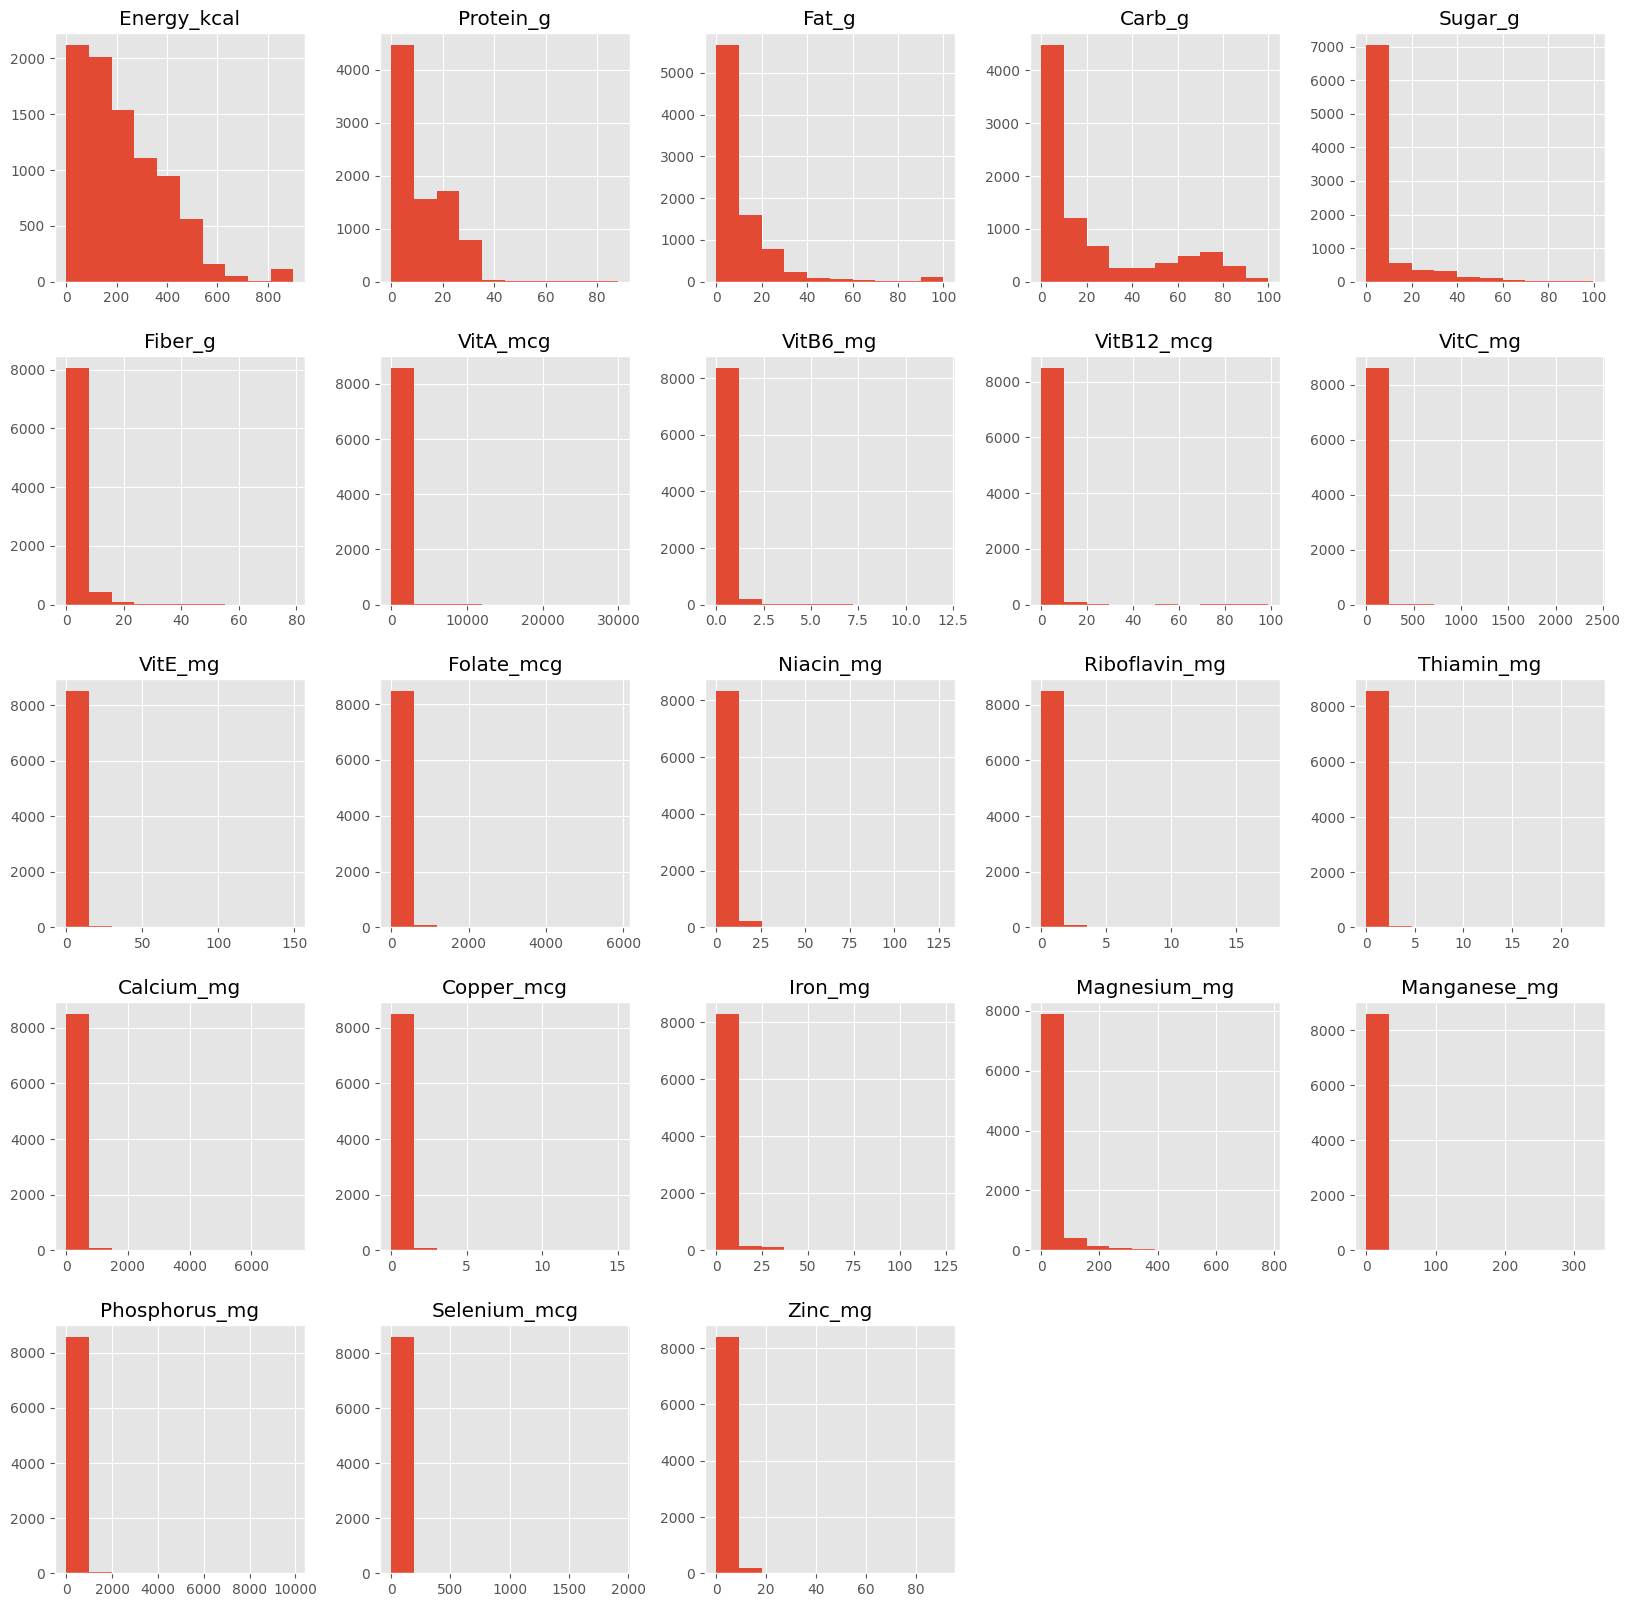

In [28]:
# Miramos la distribución de las variables con un histograma
df.hist(figsize=(20,20));

In [ ]:
# Las variables tienen asimetría a la derecha, por lo que habría que hacer algún tipo de transformación para que se parezcan a una
# distribución normal

In [29]:
# Transformación logaritmica:
df_log = df.apply(lambda x: np.log1p(x - x.min() + 1))

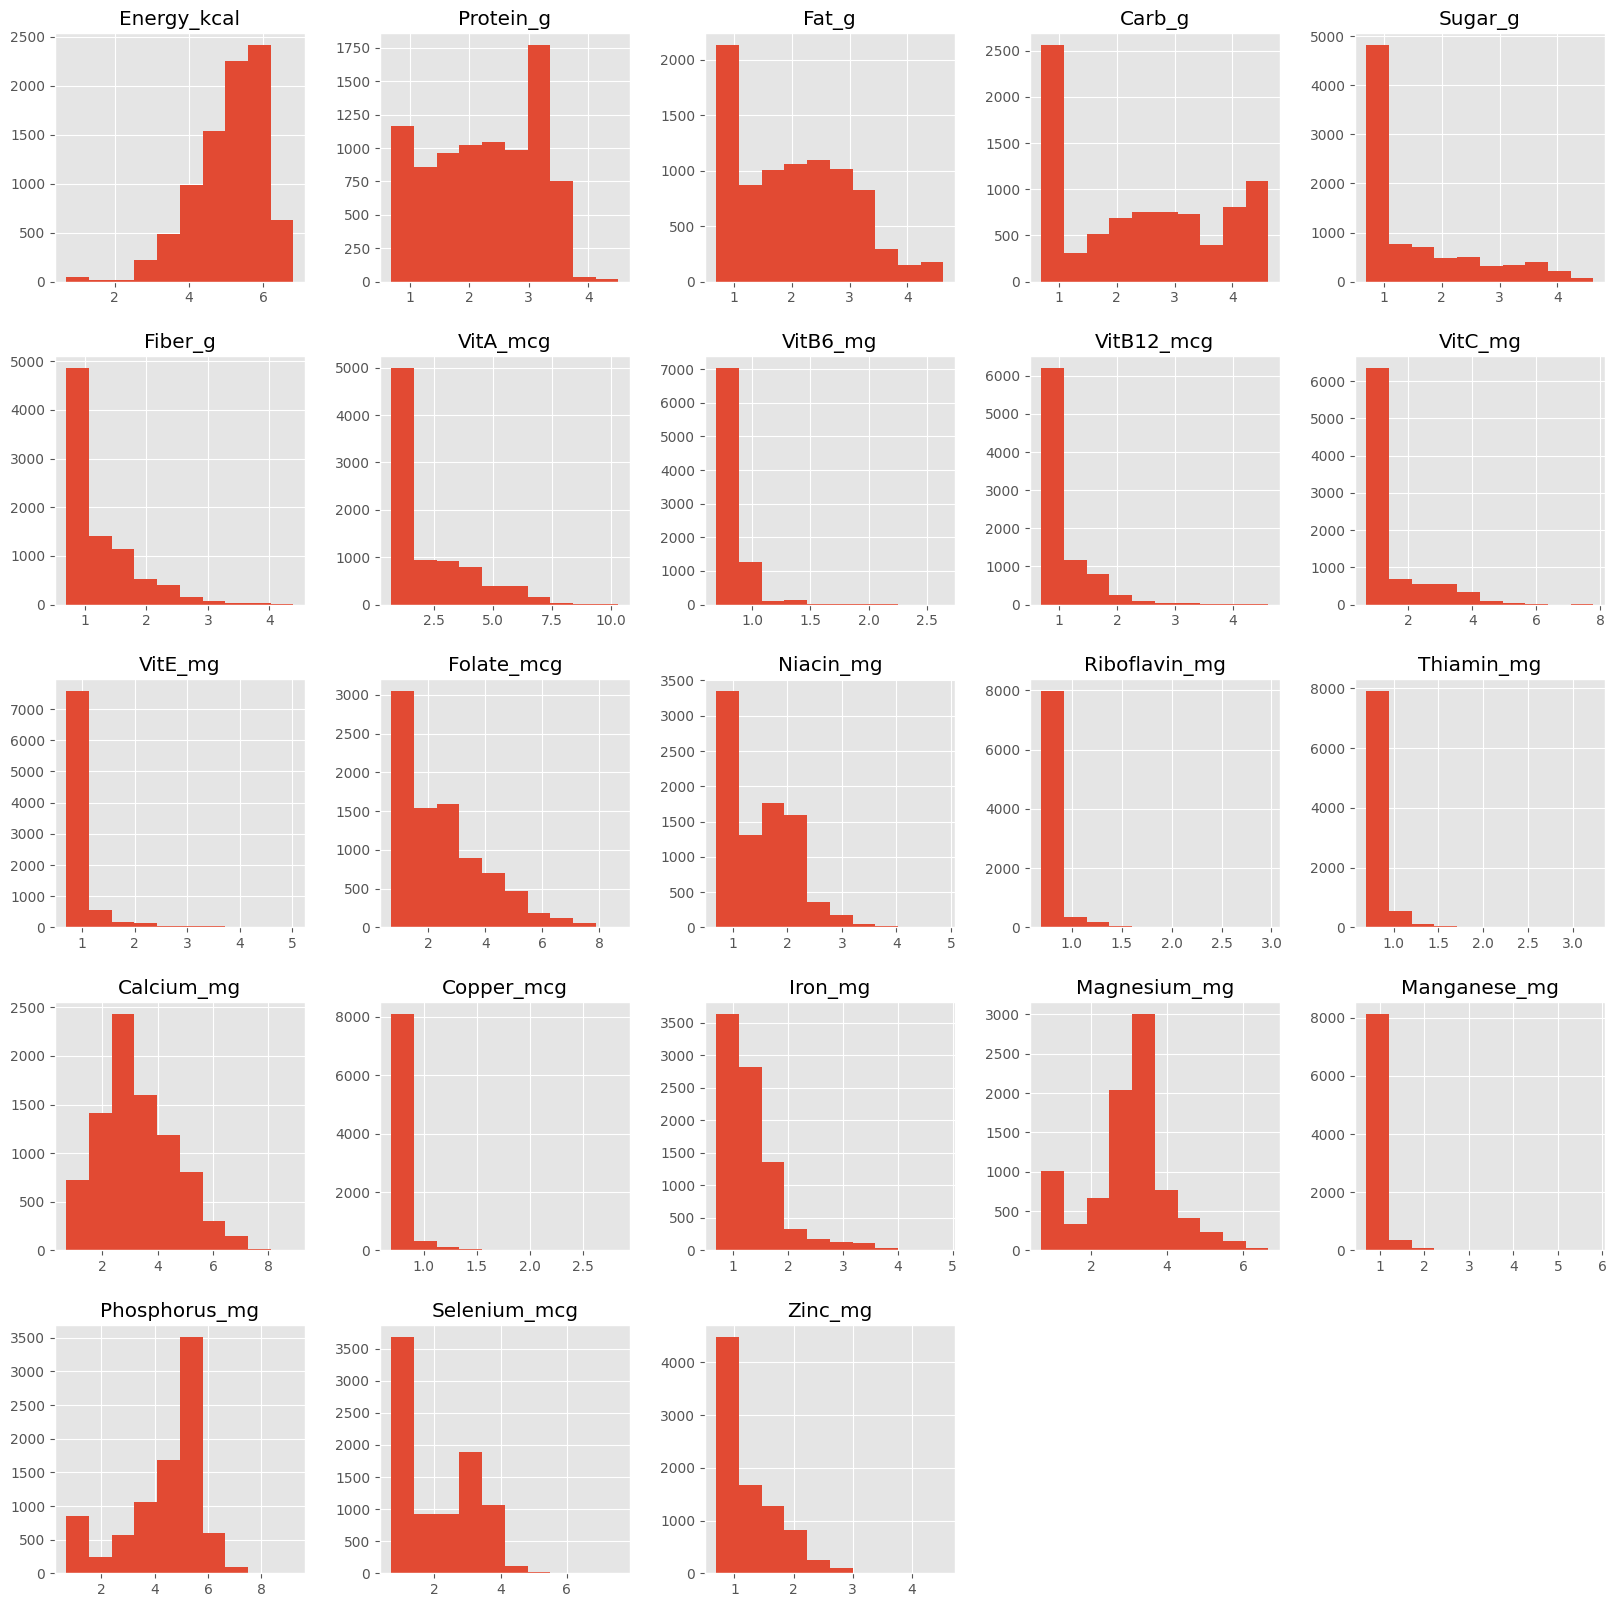

In [30]:
# Representamos de nuevo las distribuciones para ver si la transformación ha mejorado el conjunto de datos:
df_log.hist(figsize=(20,20));

In [ ]:
# Algo ha mejorado en algunas variables, pero no en todas que siguen teniendo asimetría

### Estandarizado
Estandariza cada variable.

No es necesario que dividas en train y test.

In [31]:
from sklearn.preprocessing import StandardScaler

X = df_log

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

### Implementación del PCA
Prueba a montar un PCA con todos los componentes. Para ello utiliza los datos previamente transformados y escalados.

In [32]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_std)

df_pca = pd.DataFrame(
    X_pca,
    columns=[f'PC{i+1}' for i in range(X_pca.shape[1])]
)

df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23
0,-2.065034,-0.732158,1.598623,-1.011300,3.938018,-0.127474,0.010443,-1.816838,-0.459521,0.378015,...,0.007057,0.565411,-0.351086,0.346278,0.075936,-0.153047,-0.256187,-0.036794,0.143536,-0.920103
1,-2.045300,-0.690609,1.606723,-1.006544,3.918870,-0.161215,0.048054,-1.845612,-0.479665,0.403567,...,0.057293,0.548791,-0.284129,0.290274,0.057418,-0.149445,-0.293527,-0.080150,0.134073,-0.923600
2,-2.988656,-0.835203,1.889836,-1.958197,3.954382,-1.072683,0.162430,-2.052381,-0.378567,0.410650,...,0.102767,0.624344,0.034882,0.410506,0.166780,-0.315377,-0.109606,0.090792,-0.117879,-0.854716
3,1.419413,-1.252804,0.316205,0.958086,2.484027,2.161636,0.323525,-0.697357,-0.533322,0.134704,...,-0.421456,0.703221,-0.594284,0.220526,0.588569,-0.059298,0.443933,-0.117288,0.023991,-0.044223
4,1.195213,-1.217412,0.490770,1.156609,2.737438,2.374921,0.563073,-0.667273,-0.838296,0.076835,...,-0.303474,0.432541,-0.583551,0.479096,0.505169,-0.271759,0.540777,-0.348767,-0.024654,0.017856


### Aportación de cada PCA
Visualiza en un diagrama de líneas la suma acumulada de la varianza explicativa del PCA.

Si tuviéses que quedarte con 70-75 % de la varianza original, ¿con cuántos Principal Components te quedarías?

----------------------------------------------------
Porcentaje de varianza explicada por cada componente
----------------------------------------------------


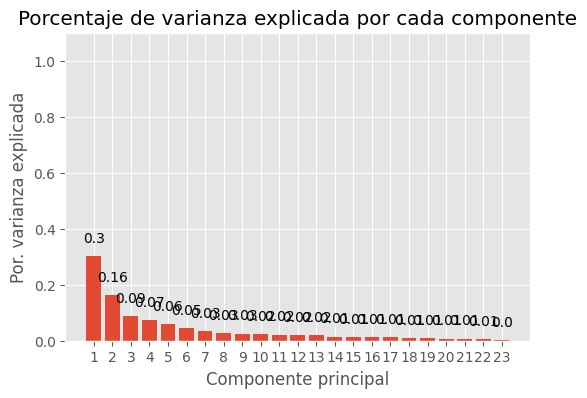

In [33]:
print('----------------------------------------------------')
print('Porcentaje de varianza explicada por cada componente')
print('----------------------------------------------------')

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))
ax.bar(
    x      = np.arange(pca.n_components_) + 1,
    height = pca.explained_variance_ratio_
)

for x, y in zip(np.arange(pca.n_components_) + 1, pca.explained_variance_ratio_):
    label = round(y, 2)
    ax.annotate(
        label,
        (x, y),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center'
    )

ax.set_xticks(np.arange(pca.n_components_) + 1)
ax.set_ylim(0, 1.1)
ax.set_title('Porcentaje de varianza explicada por cada componente')
ax.set_xlabel('Componente principal')
ax.set_ylabel('Por. varianza explicada');

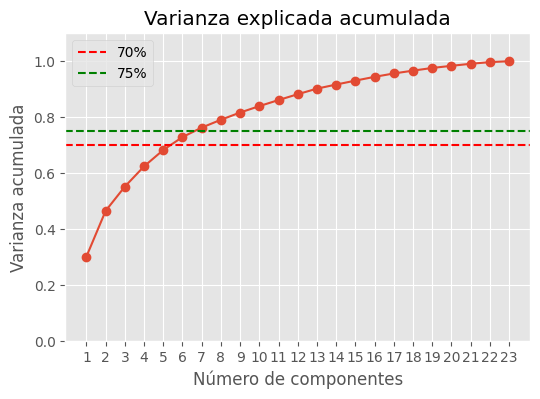

In [34]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))

ax.plot(
    np.arange(pca.n_components_) + 1,
    np.cumsum(pca.explained_variance_ratio_),
    marker='o'
)

ax.axhline(y=0.70, color='r', linestyle='--', label='70%')
ax.axhline(y=0.75, color='g', linestyle='--', label='75%')

ax.set_xticks(np.arange(pca.n_components_) + 1)
ax.set_ylim(0, 1.1)
ax.set_title('Varianza explicada acumulada')
ax.set_xlabel('Número de componentes')
ax.set_ylabel('Varianza acumulada')
ax.legend();

In [ ]:
# Me quedaría con 6 componentes puesto que el enunciado pide que nos quedemos con aquellos que expliquen la varianza entre un 
# 70 y 75%, y con 7 componentes ya nos pasamos de 75%.

## Feat. Red
Crea un nuevo PCA con X Principal Components, siendo X la cantidad de PC escogidos en el apartado anterior.

Obtén el nuevo dataset con el mismo número de registros que el original, pero en este caso con X features, que representan los PC elegidos.

In [35]:
# Como nos hemos quedado con 6 componentes: 
pca6 = PCA(n_components=6)
X_pca6 = pca6.fit_transform(X_std)

df_pca6 = pd.DataFrame(
    X_pca6,
    columns=[f'PC{i+1}' for i in range(6)]
)

df_pca6.head()

,PC1,PC2,PC3,PC4,PC5,PC6
0,-2.065034,-0.732158,1.598623,-1.011300,3.938018,-0.127474
1,-2.045300,-0.690609,1.606723,-1.006544,3.918870,-0.161215
2,-2.988656,-0.835203,1.889836,-1.958197,3.954382,-1.072683
3,1.419413,-1.252804,0.316205,0.958086,2.484027,2.161636
4,1.195213,-1.217412,0.490770,1.156609,2.737438,2.374921


### ¿Qué grupo de comida tiene los valores más altos en cada categoría?
Determina para cada Principal Component, los 3 grupos de comida (*FoodGroup*) con los valores del PC más altos.

In [38]:
# Añadir FoodGroup al dataframe de componentes principales
df_pca['FoodGroup'] = data['FoodGroup'].values
df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,FoodGroup
0,-2.065034,-0.732158,1.598623,-1.011300,3.938018,-0.127474,0.010443,-1.816838,-0.459521,0.378015,...,0.565411,-0.351086,0.346278,0.075936,-0.153047,-0.256187,-0.036794,0.143536,-0.920103,Dairy and Egg Products
1,-2.045300,-0.690609,1.606723,-1.006544,3.918870,-0.161215,0.048054,-1.845612,-0.479665,0.403567,...,0.548791,-0.284129,0.290274,0.057418,-0.149445,-0.293527,-0.080150,0.134073,-0.923600,Dairy and Egg Products
2,-2.988656,-0.835203,1.889836,-1.958197,3.954382,-1.072683,0.162430,-2.052381,-0.378567,0.410650,...,0.624344,0.034882,0.410506,0.166780,-0.315377,-0.109606,0.090792,-0.117879,-0.854716,Dairy and Egg Products
3,1.419413,-1.252804,0.316205,0.958086,2.484027,2.161636,0.323525,-0.697357,-0.533322,0.134704,...,0.703221,-0.594284,0.220526,0.588569,-0.059298,0.443933,-0.117288,0.023991,-0.044223,Dairy and Egg Products
4,1.195213,-1.217412,0.490770,1.156609,2.737438,2.374921,0.563073,-0.667273,-0.838296,0.076835,...,0.432541,-0.583551,0.479096,0.505169,-0.271759,0.540777,-0.348767,-0.024654,0.017856,Dairy and Egg Products


In [39]:
# Para cada PC, obtener los 3 FoodGroups con valores más altos
n_pcs = 6  # usamos los 6 componentes que explican el 70%

for pc in [f'PC{i+1}' for i in range(n_pcs)]:
    print(f"\n--- Top 3 FoodGroups en {pc} ---")
    top3 = (
        df_pca.groupby('FoodGroup')[pc]
        .mean()
        .sort_values(ascending=False)
        .head(3)
    )
    print(top3)


--- Top 3 FoodGroups en PC1 ---
FoodGroup
Breakfast Cereals        4.325773
Nut and Seed Products    3.165472
Spices and Herbs         2.845744
Name: PC1, dtype: float64

--- Top 3 FoodGroups en PC2 ---
FoodGroup
Spices and Herbs         3.621536
Breakfast Cereals        2.784637
Nut and Seed Products    1.908135
Name: PC2, dtype: float64

--- Top 3 FoodGroups en PC3 ---
FoodGroup
Fats and Oils            2.157506
Nut and Seed Products    1.698775
Baked Products           1.604873
Name: PC3, dtype: float64

--- Top 3 FoodGroups en PC4 ---
FoodGroup
Spices and Herbs           1.880598
Nut and Seed Products      1.823318
Cereal Grains and Pasta    1.257530
Name: PC4, dtype: float64

--- Top 3 FoodGroups en PC5 ---
FoodGroup
Fats and Oils             2.538005
Dairy and Egg Products    1.500507
Baby Foods                0.866739
Name: PC5, dtype: float64

--- Top 3 FoodGroups en PC6 ---
FoodGroup
Dairy and Egg Products    1.638523
Fast Foods                0.804462
Baked Products         